In [32]:
!pip install -q transformers torch pillow matplotlib numpy

In [33]:
import os
import sys
import socket
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

In [34]:
MODEL_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"

def check_internet(host="huggingface.co", timeout=5):
    try:
        socket.setdefaulttimeout(timeout)
        socket.gethostbyname(host)
        return True
    except OSError:
        return False

if not check_internet():
    sys.exit(
        "ERROR: Could not reach huggingface.co (DNS/network lookup failed).\n"
        "Try a different network, flush DNS, or run this notebook in Google Colab, "
        "which always has unrestricted internet access."
    )

print(f"Loading pretrained model '{MODEL_NAME}' from Hugging Face...")
processor = SegformerImageProcessor.from_pretrained(MODEL_NAME)
model = SegformerForSemanticSegmentation.from_pretrained(MODEL_NAME)
model.eval()

id2label = model.config.id2label
np.random.seed(42)
PALETTE = np.random.randint(0, 255, size=(len(id2label), 3), dtype=np.uint8)
print("Model loaded. Number of classes:", len(id2label))

Loading pretrained model 'nvidia/segformer-b0-finetuned-ade-512-512' from Hugging Face...


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Model loaded. Number of classes: 150


In [35]:
# OPTION A: uncomment to upload images directly in Google Colab
# from google.colab import files
# os.makedirs("images", exist_ok=True)
# uploaded = files.upload()
# for fname in uploaded.keys():
#     os.rename(fname, os.path.join("images", fname))

In [36]:
image_dir = "images"
image_paths = sorted(
    glob.glob(f"{image_dir}/*.jpg")
    + glob.glob(f"{image_dir}/*.jpeg")
    + glob.glob(f"{image_dir}/*.png")
)
print(f"Found {len(image_paths)} image(s):")
for p in image_paths:
    print(" -", p)
assert len(image_paths) >= 3

Found 3 image(s):
 - images\test_image_1.jpg
 - images\test_image_2.jpg
 - images\test_image_3.jpg


In [37]:
def colorize_mask(mask):
    return PALETTE[mask]

def segment_image(image_path, out_dir="outputs"):
    name = os.path.splitext(os.path.basename(image_path))[0]
    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits

    upsampled_logits = torch.nn.functional.interpolate(
        logits, size=image.size[::-1], mode="bilinear", align_corners=False
    )
    predicted_mask = upsampled_logits.argmax(dim=1)[0].numpy()

    color_mask = colorize_mask(predicted_mask)
    overlay = (0.55 * np.array(image) + 0.45 * color_mask).astype(np.uint8)

    found_ids = np.unique(predicted_mask)
    found_labels = [id2label[i] for i in found_ids]

    os.makedirs(out_dir, exist_ok=True)
    Image.fromarray(np.array(image)).save(f"{out_dir}/{name}_original.png")
    Image.fromarray(color_mask).save(f"{out_dir}/{name}_segmentation.png")
    Image.fromarray(overlay).save(f"{out_dir}/{name}_overlay.png")

    return image, color_mask, overlay, found_labels

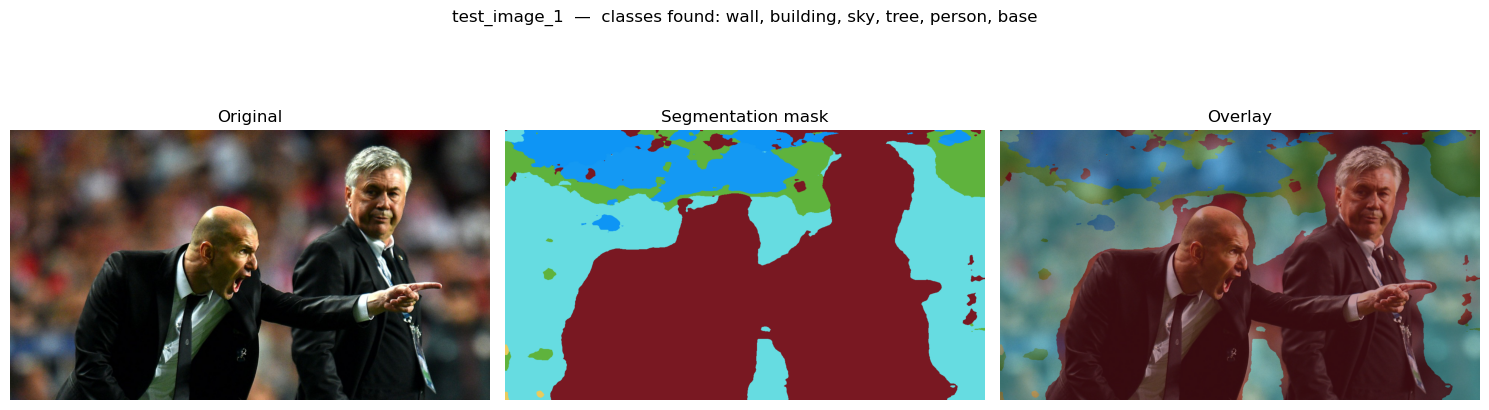

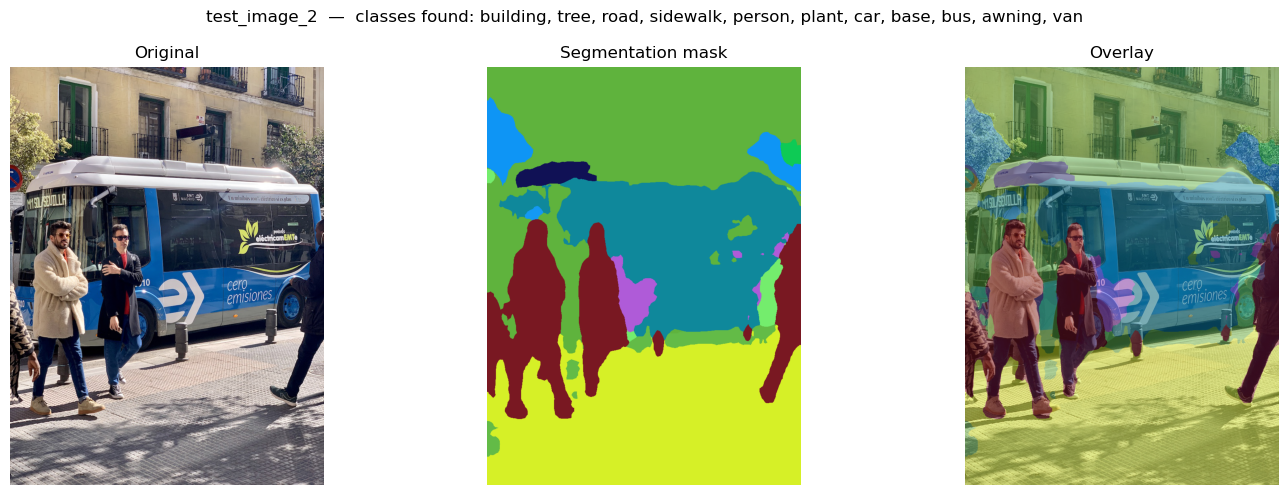

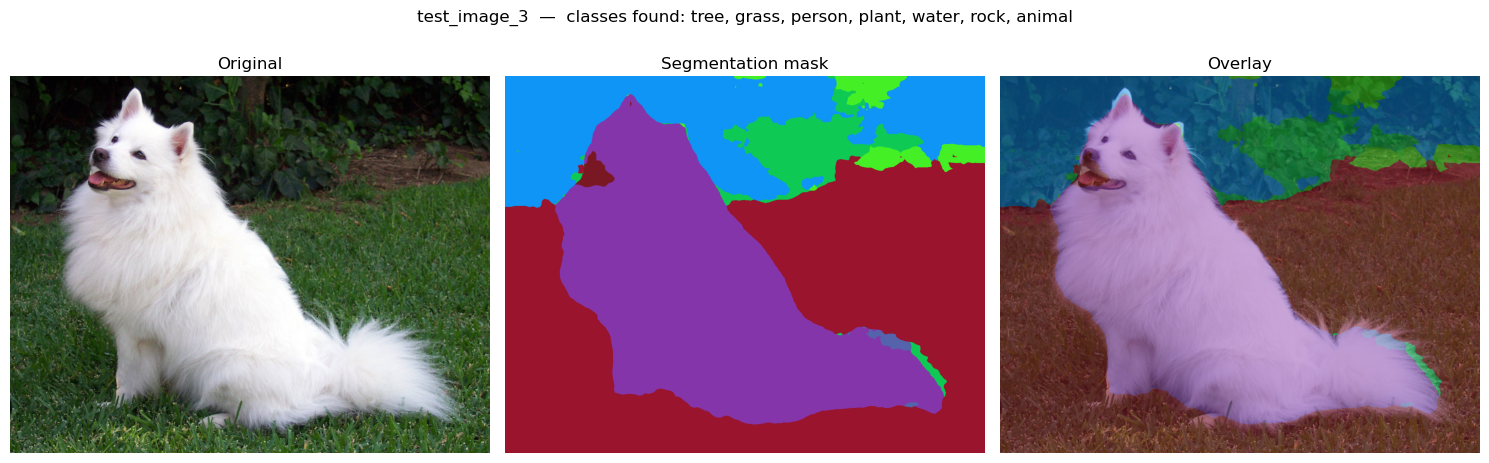

In [38]:
summary = {}

for path in image_paths:
    name = os.path.splitext(os.path.basename(path))[0]
    image, color_mask, overlay, found_labels = segment_image(path)
    summary[name] = found_labels

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(color_mask); axes[1].set_title("Segmentation mask"); axes[1].axis("off")
    axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
    fig.suptitle(f"{name}  —  classes found: {', '.join(found_labels)}")
    fig.tight_layout()
    plt.show()

In [39]:
for name, labels in summary.items():
    print(f"{name}: {', '.join(labels)}")

with open("outputs/summary.txt", "w") as f:
    for name, labels in summary.items():
        f.write(f"{name}: {', '.join(labels)}\n")
print("\nSaved to outputs/summary.txt")

test_image_1: wall, building, sky, tree, person, base
test_image_2: building, tree, road, sidewalk, person, plant, car, base, bus, awning, van
test_image_3: tree, grass, person, plant, water, rock, animal

Saved to outputs/summary.txt
